# 02 — Regime Detection

## Objective

This notebook constructs market stress regimes from observable risk features.

The goal is to transform continuous risk indicators into a small number of interpretable stress states:

| State | Label | Interpretation |
|---:|---|---|
| 0 | Normal | benign conditions |
| 1 | Elevated | risk is rising |
| 2 | Fragile | portfolio is vulnerable |
| 3 | Crisis | severe stress state |

## Research framing

The regime layer is not presented as a high-frequency prediction engine. It is a transparent state-classification layer that supports risk control.

The central idea is:

> portfolio stress can be treated as a finite-state degradation process.

As stress increases, the portfolio transitions from normal to elevated, fragile, and crisis states. Later notebooks will use this state variable to condition risk estimates and reduce allocation intensity.

## Expected outputs

This notebook should produce:

- `data/processed/regimes.csv`
- `reports/tables/regime_detection/regime_summary.csv`
- `reports/tables/regime_detection/regime_transition_matrix.csv`
- `reports/figures/regime_detection/stress_score.png`
- `reports/figures/regime_detection/regime_timeline.png`
- `reports/figures/regime_detection/regime_counts.png`
- `reports/figures/regime_detection/regime_transition_matrix.png`

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "regime_detection"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / "regime_detection"

for path in [FIGURE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RETURNS_FILE = PROCESSED_DIR / "returns.csv"
RISK_FEATURES_FILE = PROCESSED_DIR / "risk_features.csv"
REGIMES_FILE = PROCESSED_DIR / "regimes.csv"

returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)
risk_features = pd.read_csv(RISK_FEATURES_FILE, index_col=0, parse_dates=True)

returns.head(), risk_features.head()

(                 SPY       IEF       SHY       GLD       DBC
 Date                                                        
 2010-01-05  0.002644  0.004381  0.001204 -0.000911  0.001188
 2010-01-06  0.000704 -0.004044  0.000119  0.016365  0.017651
 2010-01-07  0.004212  0.000000 -0.000240 -0.006207 -0.012520
 2010-01-08  0.003323  0.001238  0.000962  0.004951 -0.000788
 2010-01-11  0.001395  0.000674  0.000480  0.013201 -0.003157,
             ew_portfolio_return  vol_21d_ann  vol_63d_ann  drawdown_252d  \
 Date                                                                       
 2010-04-06             0.001292     0.067494     0.088792      -0.002028   
 2010-04-07             0.002278     0.066902     0.088841       0.000000   
 2010-04-08             0.000373     0.066462     0.087994       0.000000   
 2010-04-09             0.003745     0.066858     0.088089       0.000000   
 2010-04-12            -0.000325     0.066951     0.088018      -0.000325   
 
             downside_vo

## Stress-score construction

We construct a transparent stress score from four components:

1. rolling volatility,
2. downside volatility,
3. drawdown severity,
4. cross-asset correlation stress.

The score is intentionally simple. It is not optimized to maximize returns. It is designed to be readable and auditable.

A higher score means higher estimated portfolio stress.

In [2]:
TRADING_DAYS = 252

def zscore(series, window=756, min_periods=252):
    """
    Rolling z-score using only local rolling information.
    """
    rolling_mean = series.rolling(window, min_periods=min_periods).mean()
    rolling_std = series.rolling(window, min_periods=min_periods).std()
    return (series - rolling_mean) / rolling_std


def average_pairwise_correlation(returns, window=63):
    """
    Rolling average pairwise correlation across assets.
    """
    values = []
    dates = []

    for end in range(window, len(returns) + 1):
        sample = returns.iloc[end - window:end]
        corr = sample.corr()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        values.append(upper.stack().mean())
        dates.append(returns.index[end - 1])

    return pd.Series(values, index=dates, name="avg_pairwise_corr_63d")


# Equal-weight portfolio return
equal_weight = pd.Series(1.0 / returns.shape[1], index=returns.columns)
portfolio_returns = returns @ equal_weight

# Wealth and drawdown
wealth = np.exp(portfolio_returns.cumsum())
drawdown = wealth / wealth.cummax() - 1.0

# Stress components
stress_components = pd.DataFrame(index=returns.index)
stress_components["vol_63d_ann"] = portfolio_returns.rolling(63).std() * np.sqrt(TRADING_DAYS)
stress_components["downside_vol_63d_ann"] = portfolio_returns.clip(upper=0).rolling(63).std() * np.sqrt(TRADING_DAYS)
stress_components["drawdown_severity"] = -drawdown
stress_components["avg_pairwise_corr_63d"] = average_pairwise_correlation(returns, window=63)

stress_components = stress_components.dropna()

# Convert each component to rolling z-scores
stress_z = pd.DataFrame(index=stress_components.index)

for column in stress_components.columns:
    stress_z[column] = zscore(stress_components[column])

stress_z = stress_z.dropna()

# Equal-weighted stress score
stress_score_raw = stress_z.mean(axis=1)
stress_score = stress_score_raw.rename("stress_score")

stress_score.to_frame().tail()

,stress_score
Date,
2026-06-04,0.207400
2026-06-05,0.806930
2026-06-08,0.785462
2026-06-09,0.868641
2026-06-10,1.073742


## Regime labeling

The regime labels are based on the historical percentile of the stress score.

This keeps the interpretation simple:

- low percentile → normal state,
- moderate percentile → elevated state,
- high percentile → fragile state,
- extreme percentile → crisis state.

The thresholds are deliberately coarse. This reduces the risk of overfitting and makes the state variable easier to interpret.

In [3]:
def expanding_percentile(series, min_periods=252):
    """
    Historical percentile of the latest value using expanding information.

    This avoids using the full sample percentile at every date.
    Early observations with insufficient history are set to NaN.
    """
    percentiles = []

    for i in range(len(series)):
        if i + 1 < min_periods:
            percentiles.append(np.nan)
        else:
            sample = series.iloc[: i + 1]
            percentile = sample.rank(pct=True).iloc[-1]
            percentiles.append(percentile)

    return pd.Series(percentiles, index=series.index, name="stress_percentile")


stress_percentile = expanding_percentile(stress_score, min_periods=252)

regime = pd.Series(index=stress_percentile.index, dtype="float")

regime[stress_percentile <= 0.50] = 0
regime[(stress_percentile > 0.50) & (stress_percentile <= 0.75)] = 1
regime[(stress_percentile > 0.75) & (stress_percentile <= 0.90)] = 2
regime[stress_percentile > 0.90] = 3

regime = regime.dropna().astype(int)
regime.name = "regime"

REGIME_LABELS = {
    0: "Normal",
    1: "Elevated",
    2: "Fragile",
    3: "Crisis",
}

regimes = pd.DataFrame(index=regime.index)
regimes["stress_score"] = stress_score.reindex(regime.index)
regimes["stress_percentile"] = stress_percentile.reindex(regime.index)
regimes["regime"] = regime
regimes["regime_label"] = regimes["regime"].map(REGIME_LABELS)

regimes.to_csv(REGIMES_FILE)

print(f"Regime file saved to: {REGIMES_FILE}")
regimes.tail()

Regime file saved to: /workspaces/regime-aware-portfolio-risk-allocation/data/processed/regimes.csv


,stress_score,stress_percentile,regime,regime_label
Date,,,,
2026-06-04,0.207400,0.659591,1,Elevated
2026-06-05,0.806930,0.839665,2,Fragile
2026-06-08,0.785462,0.833683,2,Fragile
2026-06-09,0.868641,0.854412,2,Fragile
2026-06-10,1.073742,0.893194,2,Fragile


## Regime summary

The next table checks whether the regime construction produces a sensible distribution of states.

A useful regime model should not classify almost everything as crisis or almost everything as normal. The classification should create enough observations in each state to support conditional risk analysis.

In [4]:
regime_summary = (
    regimes["regime_label"]
    .value_counts()
    .rename_axis("regime_label")
    .to_frame("n_observations")
)

regime_summary["frequency"] = regime_summary["n_observations"] / regime_summary["n_observations"].sum()

# Preserve natural order
regime_summary = regime_summary.reindex(["Normal", "Elevated", "Fragile", "Crisis"])

regime_summary.to_csv(TABLE_DIR / "regime_summary.csv")

regime_summary

,n_observations,frequency
regime_label,,
Normal,2035,0.570188
Elevated,756,0.211824
Fragile,456,0.127767
Crisis,322,0.090221


## Transition matrix

The transition matrix summarizes how persistent the stress states are.

Rows represent the current state and columns represent the next state. A high diagonal entry means that the regime is persistent.

This matrix will be reused in the SMDP-inspired stress-policy notebook.

In [5]:
def estimate_transition_matrix(regime_series, labels):
    """
    Estimate one-step transition probabilities between discrete regimes.
    """
    current_state = regime_series.iloc[:-1].values
    next_state = regime_series.iloc[1:].values

    counts = pd.crosstab(
        pd.Series(current_state, name="current_state"),
        pd.Series(next_state, name="next_state"),
    )

    counts = counts.reindex(index=labels.keys(), columns=labels.keys(), fill_value=0)
    probabilities = counts.div(counts.sum(axis=1), axis=0)

    counts.index = [labels[i] for i in counts.index]
    counts.columns = [labels[i] for i in counts.columns]

    probabilities.index = [labels[i] for i in probabilities.index]
    probabilities.columns = [labels[i] for i in probabilities.columns]

    return counts, probabilities


transition_counts, transition_matrix = estimate_transition_matrix(
    regimes["regime"],
    REGIME_LABELS,
)

transition_matrix.to_csv(TABLE_DIR / "regime_transition_matrix.csv")
transition_counts.to_csv(TABLE_DIR / "regime_transition_counts.csv")

transition_matrix

,Normal,Elevated,Fragile,Crisis
Normal,0.978378,0.020147,0.000983,0.000491
Elevated,0.056878,0.906085,0.037037,0.000000
Fragile,0.000000,0.065934,0.898901,0.035165
Crisis,0.000000,0.000000,0.052795,0.947205


## Stress-score and regime visualizations

The following figures are diagnostic.

They help answer:

1. Does the stress score spike during visibly stressed market periods?
2. Are crisis states concentrated in specific episodes?
3. Are the regimes persistent enough to be useful for risk control?
4. Do we have enough observations per state to estimate conditional risk?

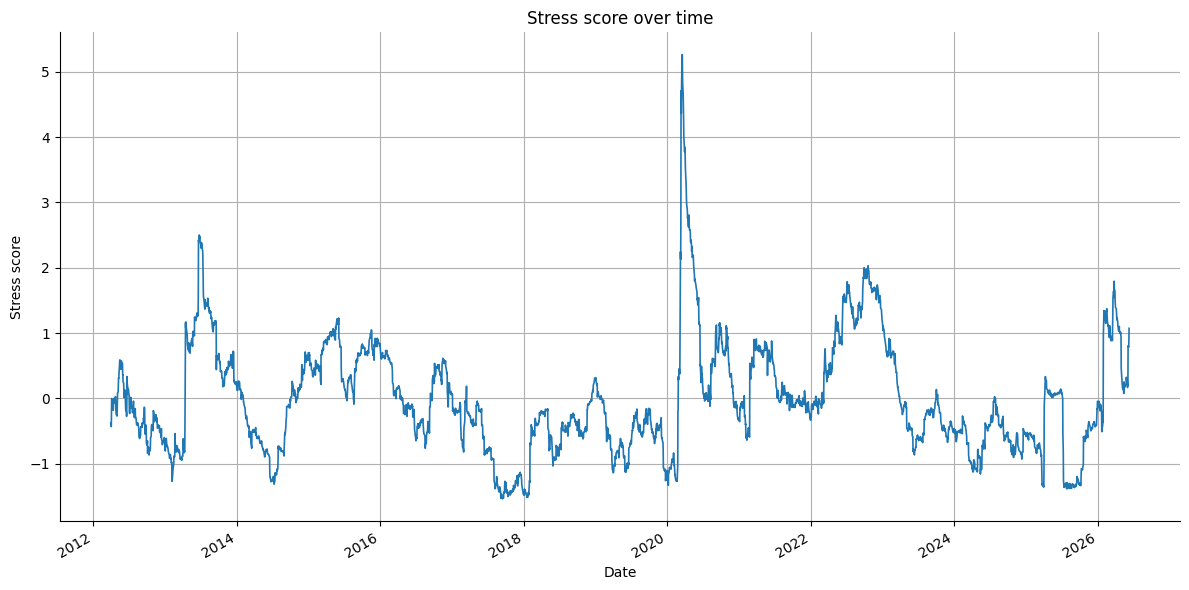

In [6]:
ax = regimes["stress_score"].plot(linewidth=1.2)

ax.set_title("Stress score over time")
ax.set_xlabel("Date")
ax.set_ylabel("Stress score")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "stress_score.png", dpi=150)
plt.show()

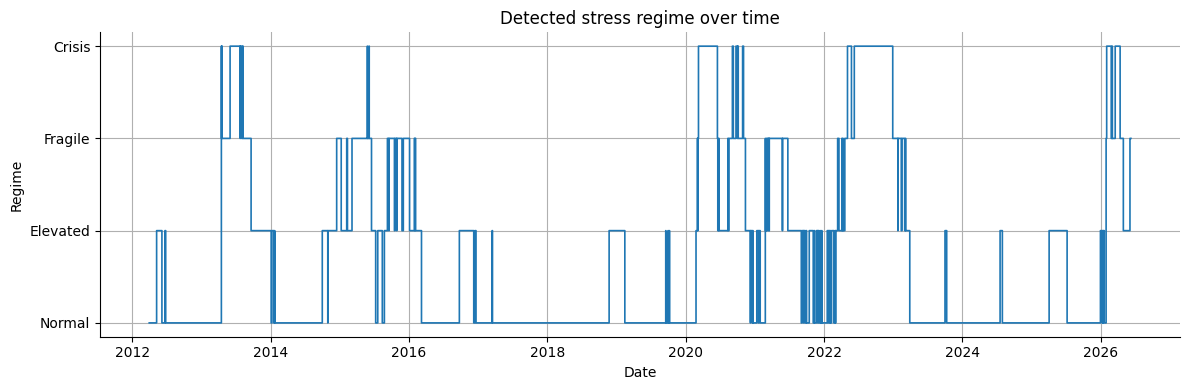

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.step(regimes.index, regimes["regime"], where="post", linewidth=1.2)

ax.set_title("Detected stress regime over time")
ax.set_xlabel("Date")
ax.set_ylabel("Regime")
ax.set_yticks(list(REGIME_LABELS.keys()))
ax.set_yticklabels([REGIME_LABELS[i] for i in REGIME_LABELS.keys()])

plt.tight_layout()
plt.savefig(FIGURE_DIR / "regime_timeline.png", dpi=150)
plt.show()

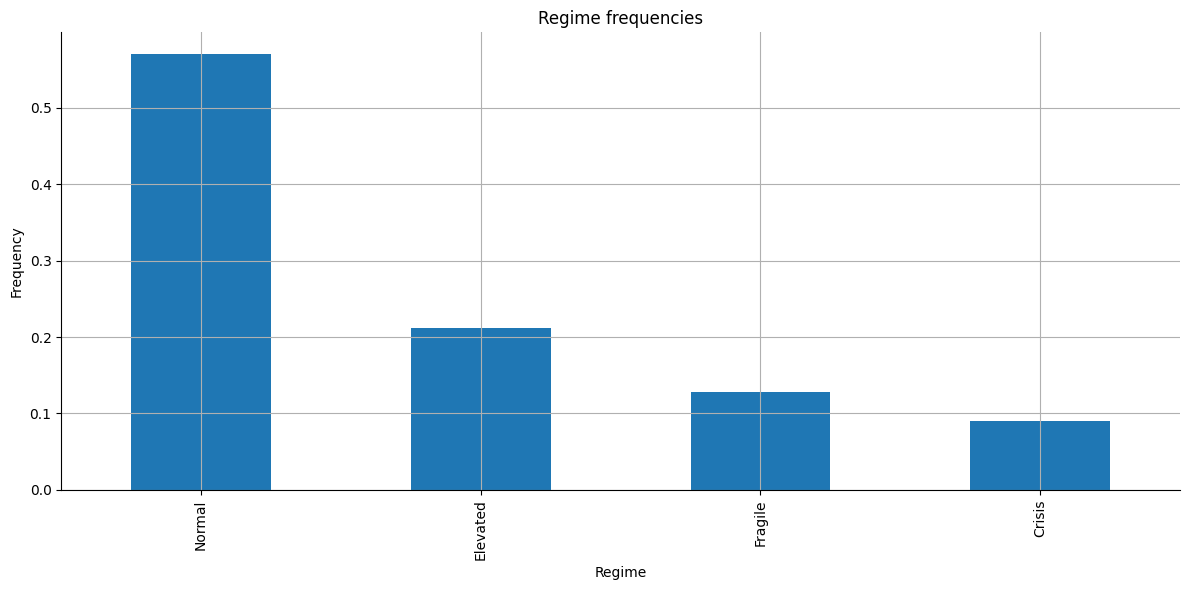

In [8]:
ax = regime_summary["frequency"].plot(kind="bar")

ax.set_title("Regime frequencies")
ax.set_xlabel("Regime")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "regime_counts.png", dpi=150)
plt.show()

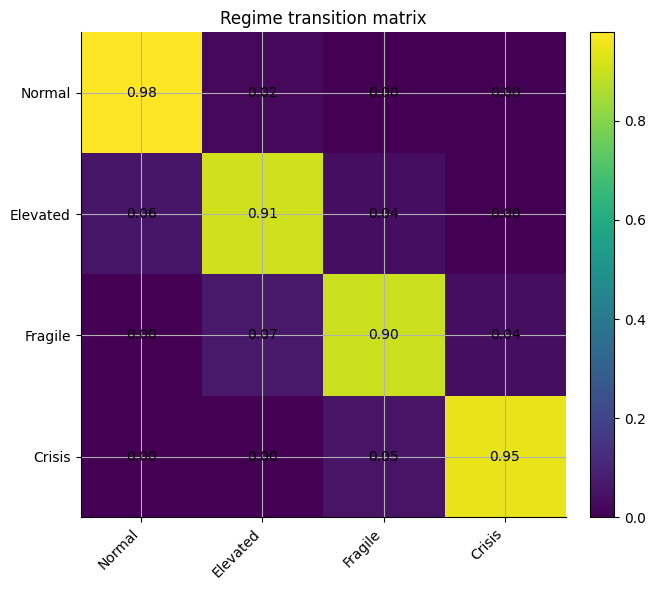

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(transition_matrix.values)

ax.set_title("Regime transition matrix")
ax.set_xticks(range(len(transition_matrix.columns)))
ax.set_xticklabels(transition_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(transition_matrix.index)))
ax.set_yticklabels(transition_matrix.index)

for i in range(transition_matrix.shape[0]):
    for j in range(transition_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{transition_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "regime_transition_matrix.png", dpi=150)
plt.show()

## Interpretation

The regime detector produces a finite-state description of portfolio stress.

The classification should be interpreted as a risk-state layer, not as a tradable signal by itself. In particular:

- the stress score is built from realized market information;
- the regime labels summarize historical stress conditions;
- the model does not claim to forecast returns;
- the purpose is to condition risk estimates and allocation intensity.

The next notebook uses these regimes to study how portfolio risk changes across normal, elevated, fragile, and crisis states.

In [ ]:
%load_ext autoreload
%autoreload 2

from regime_portfolio.data import DataConfig, compute_returns, load_price_panel
from regime_portfolio.features import make_feature_panel
from regime_portfolio.regimes import RegimeDetector, regime_durations

prices = load_price_panel(DataConfig(start="2010-01-01"))
returns = compute_returns(prices)
features = make_feature_panel(prices, returns)

detector = RegimeDetector(n_regimes=3, random_state=42).fit(features)
regimes = detector.predict(features)
proba = detector.predict_proba(features)

print(detector.transition_matrix().round(3))
print(regime_durations(regimes).groupby("regime")["duration"].describe())
print(proba.tail())


          regime_0  regime_1  regime_2
regime_0     0.994     0.004     0.003
regime_1     0.027     0.024     0.949
regime_2     0.000     0.991     0.008
        count        mean         std   min   25%    50%     75%    max
regime                                                                 
0        18.0  154.444444  136.374149  21.0  70.5  111.5  180.75  479.0
1       651.0    1.000000    0.000000   1.0   1.0    1.0    1.00    1.0
2       638.0    1.000000    0.000000   1.0   1.0    1.0    1.00    1.0
            regime_0_prob  regime_1_prob  regime_2_prob
Date                                                   
2026-06-02       0.999998       0.000002   1.006441e-08
2026-06-03       0.999999       0.000001   1.866517e-08
2026-06-04       0.999996       0.000003   1.229692e-06
2026-06-05       0.999765       0.000152   8.307579e-05
2026-06-08       0.999049       0.000542   4.092411e-04
